# EDA: Calima vs Deaths — Tenerife

**Objective:** Analyze the association between calima (proxy) and weekly mortality in Tenerife including lagged effects (lag0, lag1, lag2).

**Key variables:**
- `deaths_week`: weekly deaths (2016–2025)
- `calima_proxy_score`: heuristic index (0–4.5)
- `calima_proxy_level`: category (no_calima / possible / probable / intense)

**Sections:**
1. Load data
2. Lag0, lag1, lag2 correlations
3. Group by proxy category
4. Significant differences (ANOVA) and effect sizes (Δ deaths)
4.1 Pairwise comparisons
5. Visualizations
6. Summary

---

## 1. Load Data

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# ─── ISLAND CONFIG ─────────────────────────────────────────────────────────────
ISLAND_NAME = "tenerife"   # e.g. "gran_canaria", "tenerife", "lanzarote"
ISLAND_CODE = "tfe"   # e.g. "gcan", "tfe", "lanz"
# ───────────────────────────────────────────────────────────────────────────────

CWD = Path.cwd().resolve()

# If running from islands/<island>, go up two levels to repo root
if CWD.name == ISLAND_NAME and CWD.parent.name == "islands":
    ROOT = CWD.parent.parent
else:
    ROOT = CWD

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("CWD :", CWD)
print("ROOT:", ROOT)
print("src exists?:", (ROOT / "src").exists())

from src.utils.d25_nb_utils import (
    section, glance, checks, missing_table, num_summary,
    autosave_fig, save_table,
)

# Output directories
REPORTS_DIR = ROOT / "reports" / "islands"
FIG_DIR = REPORTS_DIR / "figures" / ISLAND_NAME
TAB_DIR = REPORTS_DIR / "tables" / ISLAND_NAME

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("FIG_DIR:", FIG_DIR)
print("TAB_DIR:", TAB_DIR)

# Load master dataset
FP = ROOT / "data/processed" / ISLAND_NAME / "master" / f"master_{ISLAND_CODE}_2016_2025.parquet"
print("FP:", FP)
assert FP.exists(), f"Missing file: {FP}"

section(f"EDA core weekly {ISLAND_NAME}")

df = pd.read_parquet(FP)
print("Loaded:", FP)

df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
print("Week range:", df["week_start"].min(), "->", df["week_start"].max())
glance(df, label=f"eda_core_weekly_{ISLAND_CODE}", n=5)

checks(
    df,
    required=["week_start", "deaths_week"],
    key=["week_start"],
    dt="week_start"
)

num_summary(df)

# Load calima proxy dataset
calima_fp = ROOT / "data" / "processed" / ISLAND_NAME / "calima" / f"calima_proxy_weekly_{ISLAND_CODE}_2016_2025.parquet"
print("Calima proxy FP:", calima_fp)

if calima_fp.exists():
    calima = pd.read_parquet(calima_fp).copy()
    calima["week_start"] = pd.to_datetime(calima["week_start"], errors="coerce")
    keep = [
        "week_start",
        "calima_proxy_score",
        "calima_proxy_level",
    ]

    calima_keep = [c for c in keep if c in calima.columns]

    # Drop overlapping columns before merge to avoid duplicates
    overlap = [c for c in calima_keep if c != "week_start" and c in df.columns]
    if overlap:
        print("Dropping overlapping columns before merge:", overlap)
        df = df.drop(columns=overlap)

    df = df.merge(calima[calima_keep], on="week_start", how="left")
    print("Merged calima proxy columns:", [c for c in calima_keep if c != "week_start"])
else:
    print("Calima proxy weekly dataset not found. Section 6.1 will be skipped.")

print("Final shape:", df.shape)

CWD : C:\Users\fdora\RA_Career\Projects\climate_mortality\islands\tenerife
ROOT: C:\Users\fdora\RA_Career\Projects\climate_mortality
src exists?: True
FIG_DIR: C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\figures\tenerife
TAB_DIR: C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\tenerife
FP: C:\Users\fdora\RA_Career\Projects\climate_mortality\data\processed\tenerife\master\master_tfe_2016_2025.parquet

EDA core weekly tenerife
Loaded: C:\Users\fdora\RA_Career\Projects\climate_mortality\data\processed\tenerife\master\master_tfe_2016_2025.parquet
Week range: 2015-12-28 00:00:00 -> 2025-12-29 00:00:00

--- eda_core_weekly_tfe ---
shape: (523, 44)

dtypes:
 week_start                     datetime64[ns]
year                                    int32
island                                 object
island_code                            object
deaths_week                           float64
deaths_missing_week                   float64
n_days       

,week_start,year,island,island_code,deaths_week,deaths_missing_week,n_days,temp_c_mean,tmax_c_mean,tmax_c_max,...,O3,days_with_pm10,days_missing_pm10,cap_heat_level_max_week,cap_dust_level_max_week,cap_heat_yellow_plus_week,cap_dust_yellow_plus_week,cap_coverage_week,calima_dai_flag,calima_level_week
0,2015-12-28,2015,tenerife,tfe,NaN,NaN,7,19.128571,22.357143,22.8,...,54.000000,3,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,2016-01-04,2016,tenerife,tfe,132.0,0.0,7,19.100000,23.342857,24.1,...,56.571429,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2,2016-01-11,2016,tenerife,tfe,162.0,0.0,7,21.642857,26.042857,29.3,...,46.571429,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
3,2016-01-18,2016,tenerife,tfe,153.0,0.0,7,20.100000,24.071429,25.4,...,60.285714,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
4,2016-01-25,2016,tenerife,tfe,117.0,0.0,7,20.628571,24.671429,27.2,...,65.142857,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0


Calima proxy FP: C:\Users\fdora\RA_Career\Projects\climate_mortality\data\processed\tenerife\calima\calima_proxy_weekly_tfe_2016_2025.parquet
Merged calima proxy columns: ['calima_proxy_score', 'calima_proxy_level']
Final shape: (523, 46)


## 2. Lags

In [2]:
# Filter out the first partial week (null deaths)
first_week = df['week_start'].min()
df = df[df['week_start'] > first_week].reset_index(drop=True)

print(f"Rows after filtering first week: {len(df)}")
print(f"Deaths nulls: {df['deaths_week'].isna().sum()}")
print(f"Calima proxy score nulls: {df['calima_proxy_score'].isna().sum()}")

# Create lag variables for calima_proxy_score
df['calima_proxy_score_lag1'] = df['calima_proxy_score'].shift(1)
df['calima_proxy_score_lag2'] = df['calima_proxy_score'].shift(2)

print("\n✅ Lag variables created:")
print(f"  lag0 (contemporaneous): {df['calima_proxy_score'].notna().sum()} non-null")
print(f"  lag1 (1 week prior):    {df['calima_proxy_score_lag1'].notna().sum()} non-null")
print(f"  lag2 (2 weeks prior):   {df['calima_proxy_score_lag2'].notna().sum()} non-null")

Rows after filtering first week: 522
Deaths nulls: 0
Calima proxy score nulls: 0

✅ Lag variables created:
  lag0 (contemporaneous): 522 non-null
  lag1 (1 week prior):    521 non-null
  lag2 (2 weeks prior):   520 non-null


In [3]:
# Correlations: deaths_week vs calima_proxy_score at different lags
corr_lag0 = df['deaths_week'].corr(df['calima_proxy_score'])
corr_lag1 = df['deaths_week'].corr(df['calima_proxy_score_lag1'])
corr_lag2 = df['deaths_week'].corr(df['calima_proxy_score_lag2'])

corr_summary = pd.DataFrame({
    'lag': ['lag0 (same week)', 'lag1 (1 week prior)', 'lag2 (2 weeks prior)'],
    'correlation': [corr_lag0, corr_lag1, corr_lag2],
    'n_pairs': [
        df[['deaths_week', 'calima_proxy_score']].notna().all(axis=1).sum(),
        df[['deaths_week', 'calima_proxy_score_lag1']].notna().all(axis=1).sum(),
        df[['deaths_week', 'calima_proxy_score_lag2']].notna().all(axis=1).sum(),
    ]
})

print("Correlations: deaths_week vs calima_proxy_score\n")
print(corr_summary.to_string(index=False))

# Save
corr_summary.to_csv(TAB_DIR / 'calima_deaths_lags_correlation.csv', index=False)
print("\n✅ Saved: calima_deaths_lags_correlation.csv")

Correlations: deaths_week vs calima_proxy_score

                 lag  correlation  n_pairs
    lag0 (same week)     0.238648      522
 lag1 (1 week prior)     0.229979      521
lag2 (2 weeks prior)     0.255568      520

✅ Saved: calima_deaths_lags_correlation.csv


**Interpretation:** Check whether the strongest correlation is at lag0 (same week) or lagged (lag1, lag2).
- If strongest at lag0: calima impacts mortality quickly, or both variables co-vary contemporaneously without a lag-driven causal mechanism.
- If strongest at lag1/lag2: suggests a delayed mortality effect from calima exposure.

## 3. Group by Proxy Category

In [4]:
# Group by calima_proxy_level and compute deaths statistics
level_order = ['no_calima', 'possible', 'probable', 'intense']

deaths_by_level = (
    df.groupby('calima_proxy_level', observed=True)['deaths_week']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .reindex(level_order)
)

print("Deaths statistics by calima proxy level:\n")
print(deaths_by_level.round(2))

# Compute Δ deaths (intense vs baseline)
baseline = deaths_by_level.loc['no_calima', 'mean']
intense  = deaths_by_level.loc['intense', 'mean']
delta    = intense - baseline

print(f"\nΔ deaths (intense vs no_calima): {delta:.2f} deaths/week")

# Save
deaths_by_level.to_csv(TAB_DIR / 'calima_level_v_deaths_stats.csv')
print("\n✅ Saved: calima_level_v_deaths_stats.csv")

Deaths statistics by calima proxy level:

                    count    mean  median    std    min    max
calima_proxy_level                                            
no_calima             310  138.85   138.0  21.53   92.0  200.0
possible              141  139.43   138.0  21.67  100.0  198.0
probable               31  141.39   140.0  24.79  103.0  214.0
intense                40  157.38   157.0  22.31  114.0  208.0

Δ deaths (intense vs no_calima): 18.52 deaths/week

✅ Saved: calima_level_v_deaths_stats.csv


**Interpretation:**
- Check whether the relationship is monotonic (more calima → more deaths) or non-monotonic.
- If only 'intense' shows elevated deaths, the proxy may be capturing real signal only at the extremes.

## 4. Significant Differences (ANOVA) and Effect Sizes (Δ deaths)

In [5]:
from scipy import stats

# ANOVA: Are there significant differences across groups?
groups = [df[df['calima_proxy_level'] == level]['deaths_week'].dropna()
          for level in level_order]
f_stat, p_value = stats.f_oneway(*groups)

print("ANOVA: Deaths across calima proxy levels")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value:     {p_value:.6f}")

if p_value < 0.05:
    print("✅ Significant difference (p < 0.05)")
else:
    print("⚠️ Not significant at α=0.05")

# Effect size: eta-squared (η²)
grand_mean = df['deaths_week'].mean()
ss_between = sum(len(groups[i]) * (groups[i].mean() - grand_mean)**2
                 for i in range(len(groups)))
ss_total   = sum((df['deaths_week'] - grand_mean)**2)
eta_squared = ss_between / ss_total

print(f"\nEffect size (η²): {eta_squared:.4f}")
print(f"  0.01 = small | 0.06 = medium | 0.14+ = large")

ANOVA: Deaths across calima proxy levels
F-statistic: 8.6851
P-value:     0.000012
✅ Significant difference (p < 0.05)

Effect size (η²): 0.0479
  0.01 = small | 0.06 = medium | 0.14+ = large


**Interpretation:**
- F-statistic and p-value indicate whether group differences are statistically significant.
- η² (eta-squared) quantifies the proportion of variance in deaths explained by the calima proxy level:
  - < 0.01: negligible | 0.01–0.06: small | 0.06–0.14: medium | ≥ 0.14: large

## 4.1 Pairwise Comparisons

In [6]:
from scipy.stats import ttest_ind

# Pairwise t-tests: intense vs all other levels
print("Pairwise t-tests: intense vs other levels\n")

intense_deaths = df[df['calima_proxy_level'] == 'intense']['deaths_week'].dropna()

for level in ['no_calima', 'possible', 'probable']:
    other_deaths = df[df['calima_proxy_level'] == level]['deaths_week'].dropna()
    t_stat, p_val = ttest_ind(intense_deaths, other_deaths)
    delta_pw = intense_deaths.mean() - other_deaths.mean()

    sig = "✅" if p_val < 0.05 else "⚠️"
    print(f"{sig} intense vs {level:12s}: Δ = {delta_pw:6.2f}, t = {t_stat:6.3f}, p = {p_val:.6f}")

Pairwise t-tests: intense vs other levels

✅ intense vs no_calima   : Δ =  18.52, t =  5.100, p = 0.000001
✅ intense vs possible    : Δ =  17.95, t =  4.593, p = 0.000008
✅ intense vs probable    : Δ =  15.99, t =  2.853, p = 0.005710


**Interpretation:**
- Each row shows whether 'intense' calima weeks have significantly more deaths than the comparison group.
- Note which contrast has the largest Δ — this indicates the most affected baseline group.

## 5. Visualizations

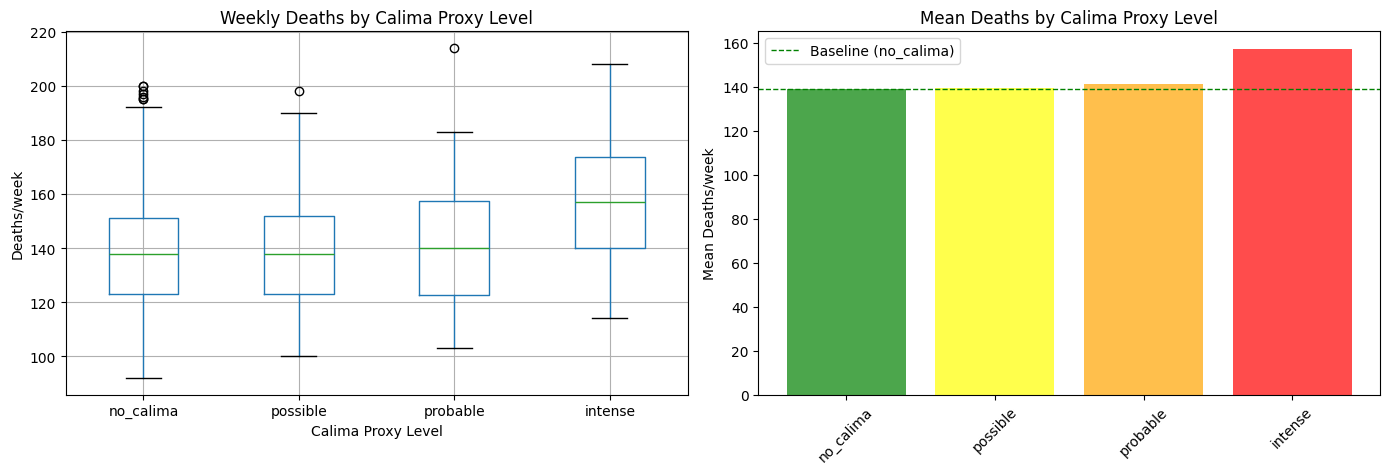

✅ Saved: eda_calima_deaths_by_level.png


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Boxplot: deaths distribution by calima level
ax = axes[0]
plot_df = df.dropna(subset=['calima_proxy_level', 'deaths_week']).copy()
plot_df['calima_proxy_level'] = pd.Categorical(
    plot_df['calima_proxy_level'],
    categories=level_order,
    ordered=True
)
plot_df.boxplot(column='deaths_week', by='calima_proxy_level', ax=ax)
ax.set_title('Weekly Deaths by Calima Proxy Level')
ax.set_xlabel('Calima Proxy Level')
ax.set_ylabel('Deaths/week')
plt.sca(ax)
plt.xticks(rotation=0)

# 2. Bar chart: mean deaths by calima level
ax = axes[1]
means = deaths_by_level['mean'].reindex(level_order)
colors = ['green', 'yellow', 'orange', 'red']
ax.bar(range(len(level_order)), means.values, color=colors, alpha=0.7)
ax.set_xticks(range(len(level_order)))
ax.set_xticklabels(level_order, rotation=45)
ax.set_ylabel('Mean Deaths/week')
ax.set_title('Mean Deaths by Calima Proxy Level')
# Baseline reference line
ax.axhline(y=means['no_calima'], color='green', linestyle='--', linewidth=1, label='Baseline (no_calima)')
ax.legend()

fig.suptitle('')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_calima_deaths_by_level.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: eda_calima_deaths_by_level.png")

## 6. Summary

In [8]:
# Compute strongest lag label
lag_values = {'lag0 (same week)': corr_lag0, 'lag1 (1 week prior)': corr_lag1, 'lag2 (2 weeks prior)': corr_lag2}
strongest_lag = max(lag_values, key=lambda k: abs(lag_values[k]))
strongest_corr = lag_values[strongest_lag]

# Compute Δ (intense vs possible) for summary
mean_possible = deaths_by_level.loc['possible', 'mean']
delta_vs_possible = intense - mean_possible

summary = pd.DataFrame({
    'Finding': [
        'Strongest lag (highest |r|)',
        'ANOVA F-statistic',
        'ANOVA p-value',
        'Effect size (η²)',
        'Δ deaths (intense vs no_calima)',
        'Δ deaths (intense vs possible)',
        'Sample size - intense weeks',
    ],
    'Value': [
        f'{strongest_lag} (r={strongest_corr:.3f})',
        f'{f_stat:.2f}',
        f'{p_value:.2e}',
        f'{eta_squared:.4f} ({"large" if eta_squared >= 0.14 else "medium" if eta_squared >= 0.06 else "small" if eta_squared >= 0.01 else "negligible"})',
        f'+{delta:.2f} deaths/week',
        f'+{delta_vs_possible:.2f} deaths/week',
        f'{len(groups[3])} weeks',
    ]
})

print("\n" + "="*70)
print(f"SUMMARY: Calima Proxy vs Deaths — {ISLAND_NAME.replace('_', ' ').title()}")
print("="*70 + "\n")
print(summary.to_string(index=False))

# Save
summary.to_csv(TAB_DIR / 'eda_calima_deaths_summary.csv', index=False)
print("\n✅ Saved: eda_calima_deaths_summary.csv")


SUMMARY: Calima Proxy vs Deaths — Tenerife

                        Finding                          Value
    Strongest lag (highest |r|) lag2 (2 weeks prior) (r=0.256)
              ANOVA F-statistic                           8.69
                  ANOVA p-value                       1.25e-05
               Effect size (η²)                 0.0479 (small)
Δ deaths (intense vs no_calima)             +18.52 deaths/week
 Δ deaths (intense vs possible)             +17.95 deaths/week
    Sample size - intense weeks                       40 weeks

✅ Saved: eda_calima_deaths_summary.csv
